# Predecir el futuro

## Introducción

En esta sesión, aprenderemos a utilizar las librerias de `prophet` y `pmdarima` de Python para realizar análisis de series temporales de manera automatizada. A través de un caso práctico dentro de una empresa, comprenderemos cómo aplicar las librerias para predecir ventas futuras y tomar decisiones estratégicas basadas en datos.

## Objetivos de Aprendizaje

- Comprender los conceptos básicos del análisis de series temporales.
- Aprender a utilizar las librerías [`prophet`](https://facebook.github.io/prophet/) y [`pmdarima`](https://pypi.org/project/pmdarima/) para modelado automatizado de series temporales.
- Aplicar técnicas de predicción para resolver un problema empresarial real.
- Interpretar los resultados y extraer insights accionables.

---

## Caso Práctico: ForecastTech Inc.

### Contexto de la Empresa

RazerTech Inc. es una empresa dedicada a la fabricación y venta de dispositivos electrónicos. A lo largo de los últimos tres años, ha experimentado fluctuaciones en sus ventas mensuales debido a factores estacionales y tendencias del mercado.

### Problema Empresarial

El departamento de finanzas necesita prever las ventas mensuales para el próximo año con el fin de:

- Optimizar la gestión del inventario.
- Planificar estrategias de marketing.
- Ajustar la producción y recursos.

### Objetivo de la Sesión

Utilizar las paqueterías de para crear un modelo que prediga las ventas mensuales de RazerTech Inc. para el próximo año, y proporcionar recomendaciones basadas en el análisis.

---

## Configuración del Entorno

Antes de comenzar, asegúrate de tener instaladas las siguientes librerías:

```bash
pip install pmdarima prophet

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from prophet import Prophet

## Paso 1: Importación de Librerías y Carga de Datos
Comenzamos importando las librerías necesarias y cargando el conjunto de datos proporcionado por la empresa.

In [26]:
df = pd.read_csv('data/ventas_mensuales.csv', parse_dates=['Fecha'])
df.tail()

,Fecha,Ventas
115,2024-08-31,558.33
116,2024-09-30,538.18
117,2024-10-31,491.54
118,2024-11-30,628.78
119,2024-12-31,937.60


## Paso 2: Exploración y Visualización de los Datos
Antes de modelar, es importante entender la naturaleza de nuestros datos.

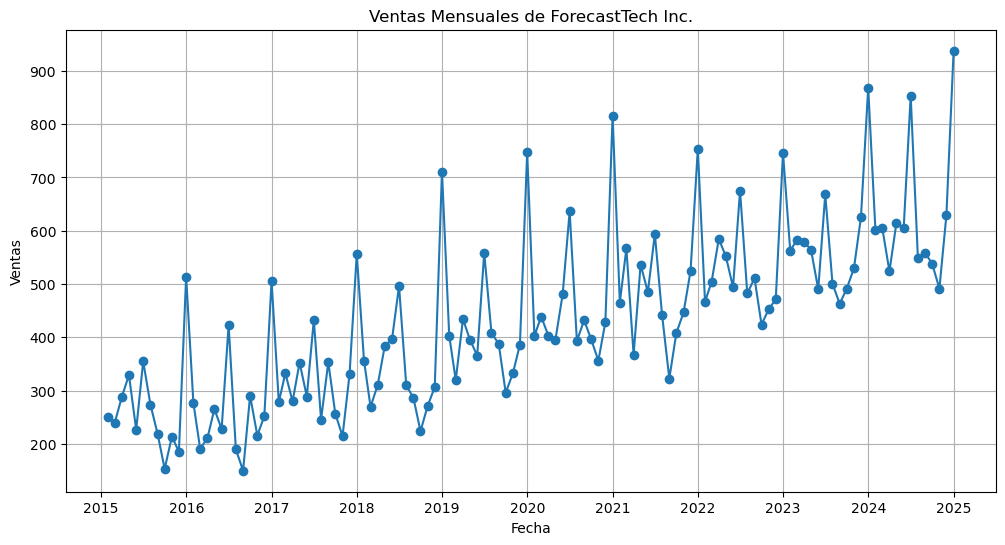

In [19]:
plt.figure(figsize=(12,6))
plt.plot(df['Fecha'], df['Ventas'], marker='o')
plt.title('Ventas Mensuales de ForecastTech Inc.')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()

## Paso 3: Configuración del Modelo
Las librerías se harán cargo del entrenamiento usando los datos.

### PMD ARIMA

In [39]:
df_autoarima = df.set_index('Fecha')

train_size = int(len(df_autoarima)*0.8)
train, test = train_test_split(df_autoarima, train_size=train_size)

auto_arima_model = pm.auto_arima(train, seasonal=True, m=12)

forecasts = auto_arima_model.predict(test.shape[0])
forecasts.head()

2023-01-31    546.414271
2023-02-28    538.803128
2023-03-31    530.041694
2023-04-30    557.751799
2023-05-31    522.761184
Freq: ME, dtype: float64

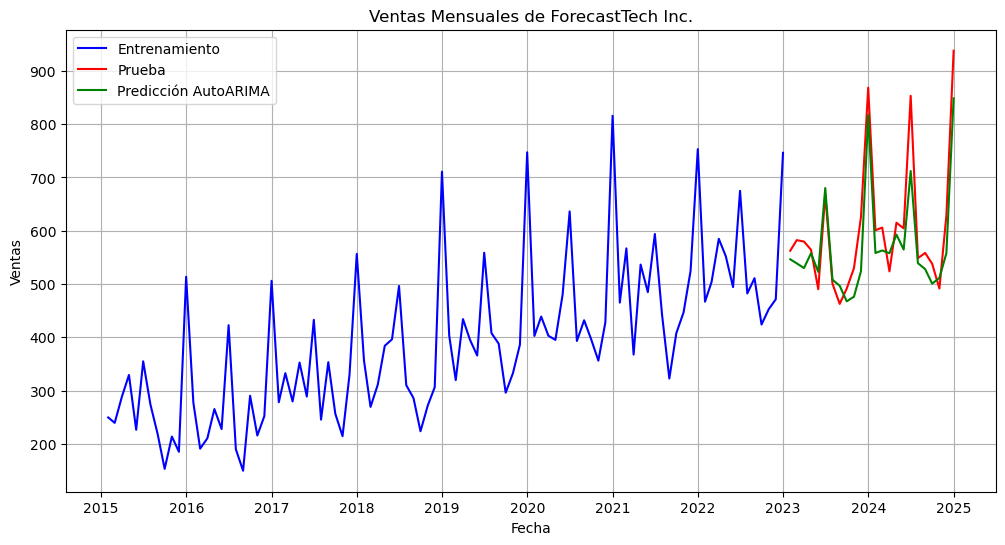

In [47]:
plt.figure(figsize=(12,6))
plt.plot(df['Fecha'][:train_size], train, label='Entrenamiento', c='blue')
plt.plot(df['Fecha'][train_size:], test, label='Prueba', c='red')
plt.plot(df['Fecha'][train_size:], forecasts, label='Predicción AutoARIMA', c='green')
plt.title('Ventas Mensuales de ForecastTech Inc.')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

### Prophet

In [ ]:
df_prophet = df.rename({'Fecha':'ds', 'Ventas':'y'}, axis=1)
train_prophet = df_prophet.iloc[:train_size]
test_prophet = df_prophet.iloc[train_size:]

modelo_prophet = Prophet()
modelo_prophet.fit(train_prophet)

future = modelo_prophet.make_future_dataframe(periods=len(test_prophet), freq='MS')
future.head() # Solo son fechas

14:02:53 - cmdstanpy - INFO - Chain [1] start processing
14:02:53 - cmdstanpy - INFO - Chain [1] done processing


,ds
0,2015-01-31
1,2015-02-28
2,2015-03-31
3,2015-04-30
4,2015-05-31


In [44]:
forecast = modelo_prophet.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
115,2024-08-01,451.888500,403.137032,500.866258
116,2024-09-01,460.390588,415.285210,509.732943
117,2024-10-01,672.089142,623.827355,721.365482
118,2024-11-01,476.506765,425.291782,526.114636
119,2024-12-01,631.966506,580.753601,682.738588


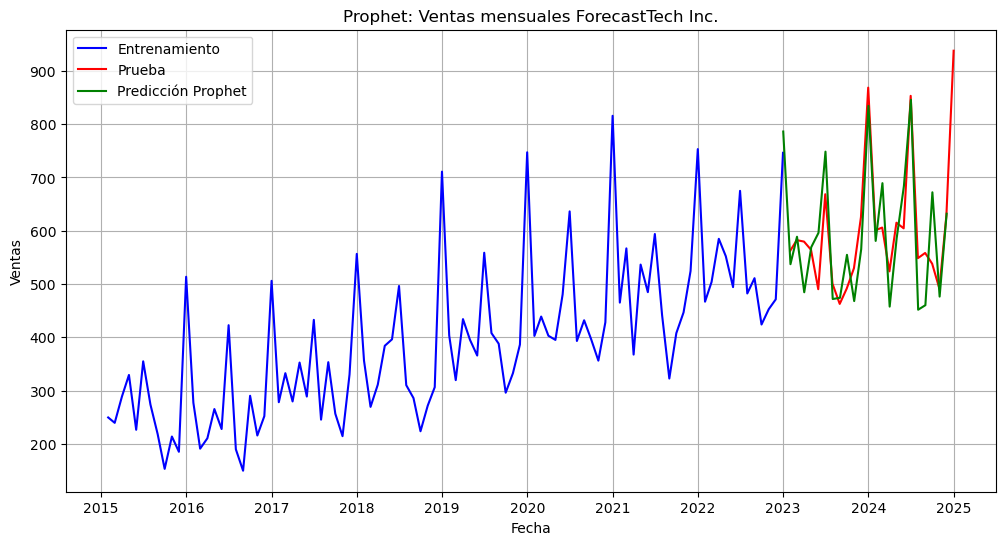

In [45]:
forecast_train = forecast.iloc[:train_size]
forecast_test = forecast.iloc[train_size:]

plt.figure(figsize=(12,6))
plt.plot(train_prophet['ds'], train_prophet['y'], label='Entrenamiento', color='blue')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Prueba', color='red')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Predicción Prophet', color='green')
plt.title('Prophet: Ventas mensuales ForecastTech Inc.')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


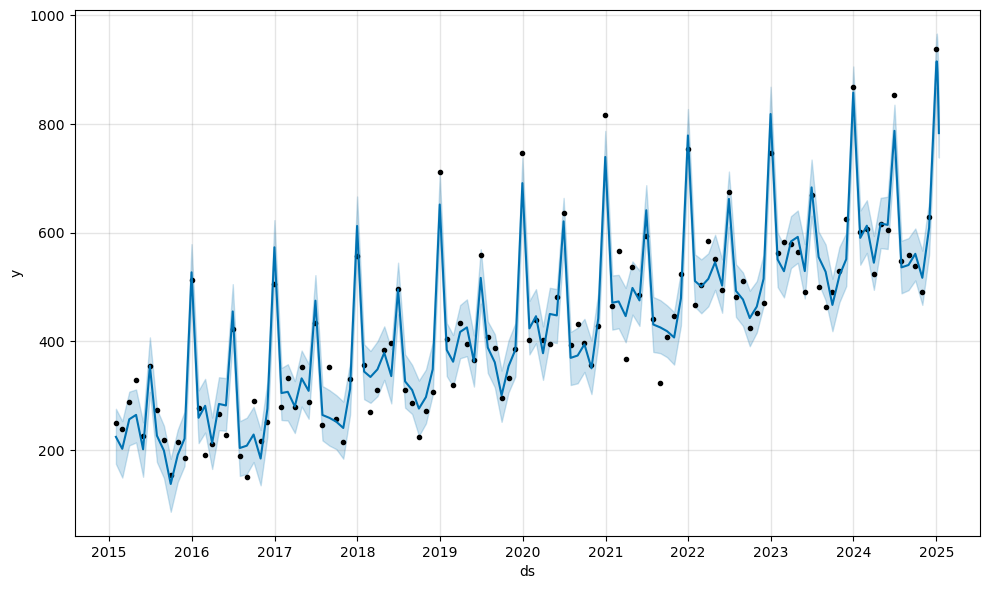

In [29]:
fig1 = prophet_model.plot(forecast)

## Paso 4: Evaluación del Modelo
Predicción y Comparación con Datos Reales

Para saber qué tan bien está funcionando nuestro modelo, debemos comparar las predicciones con los valores reales del conjunto de prueba (en el caso de pmdarima) o con los datos observados recientes (en el caso de prophet).

### Evaluación del modelo auto_arima
Calculamos el Error Absoluto Medio (MAE) y el Error Cuadrático Medio (RMSE).

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_arima = mean_absolute_error(test, forecasts)
rmse_arima = np.sqrt(mean_squared_error(test, forecasts))

print(f"MAE (Auto-ARIMA): {mae_arima:.2f}")
print(f"RMSE (Auto-ARIMA): {rmse_arima:.2f}")


MAE (Auto-ARIMA): 42.13
RMSE (Auto-ARIMA): 52.43


### Evaluación del modelo prophet
Para evaluar prophet, comparamos las predicciones en el periodo de testeo contra los valores reales, si existen. Alternativamente, si solo queremos evaluar visualmente:

/var/folders/p_/t355wf8d61177pp2l7_8j9480000gn/T/ipykernel_48950/398715860.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


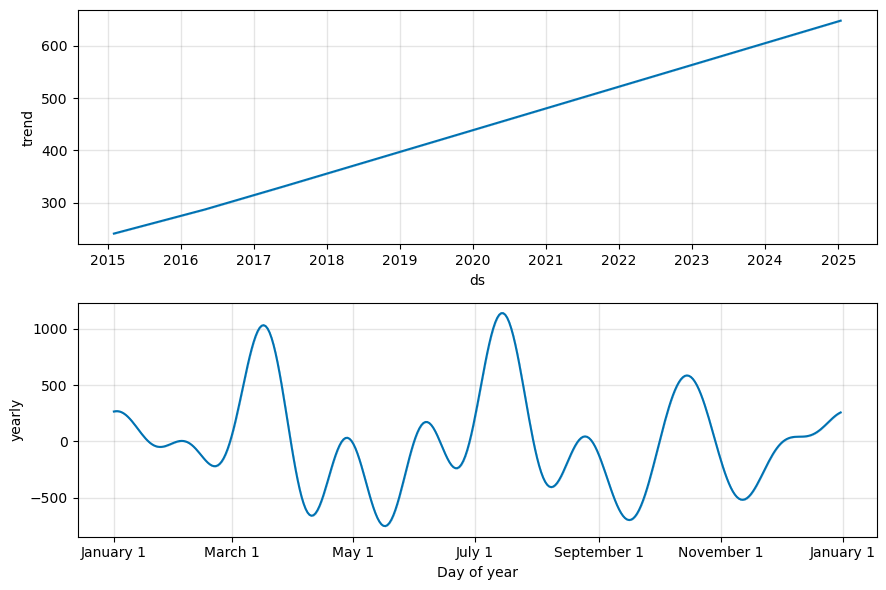

In [34]:
from prophet.plot import plot_components_plotly

fig2 = prophet_model.plot_components(forecast)
fig2.show()

También podemos calcular métricas si comparamos el yhat con los valores reales en el periodo reciente:

In [35]:
real_vs_pred = df_prophet.merge(forecast[['ds', 'yhat']], on='ds', how='left')
valid = real_vs_pred[-12:]

mae_prophet = mean_absolute_error(valid['y'], valid['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(valid['y'], valid['yhat']))

print(f"MAE (Prophet): {mae_prophet:.2f}")
print(f"RMSE (Prophet): {rmse_prophet:.2f}")


MAE (Prophet): 20.49
RMSE (Prophet): 25.93


## Paso 5: Predicción Futura

Una vez evaluado el modelo, lo utilizamos para hacer predicciones de los próximos 12 meses.

### Con auto_arima

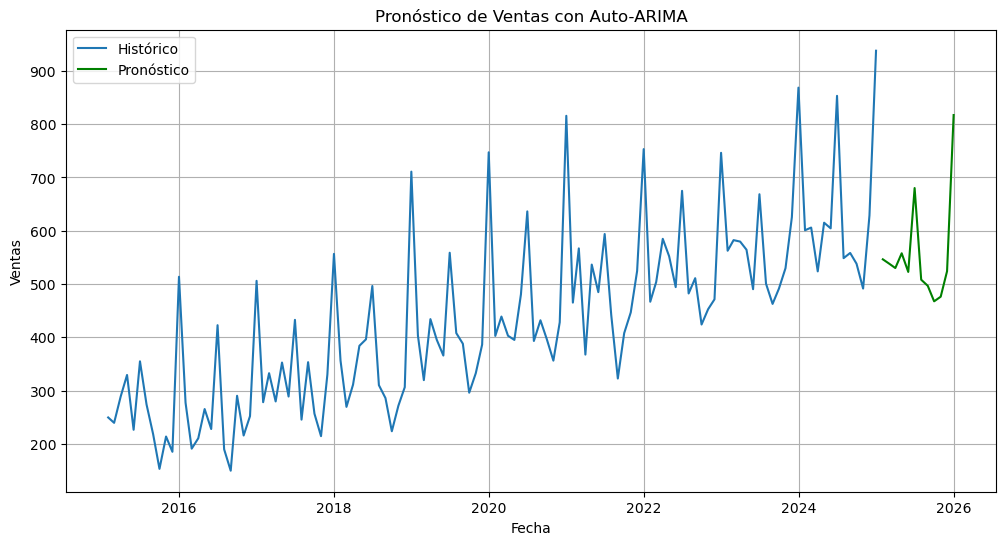

In [ ]:
n_months = 12
future_forecasts_arima = auto_arima_model.predict(n_periods=n_months)

future_dates = pd.date_range(start=df_autoarima.index[-1] + pd.DateOffset(months=1), periods=n_months, freq='MS')
forecast_df_arima = pd.DataFrame({'Fecha': future_dates, 'Predicción': future_forecasts_arima})

plt.figure(figsize=(12,6))
plt.plot(df_autoarima.index, df_autoarima['Ventas'], label='Histórico')
plt.plot(forecast_df_arima['Fecha'], forecast_df_arima['Predicción'], label='Pronóstico', color='green')
plt.title('Pronóstico de Ventas con Auto-ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


### Con prophet

Ya generamos forecast con 12 periodos futuros. Solo visualizamos los valores proyectados:

14:08:24 - cmdstanpy - INFO - Chain [1] start processing
14:08:24 - cmdstanpy - INFO - Chain [1] done processing


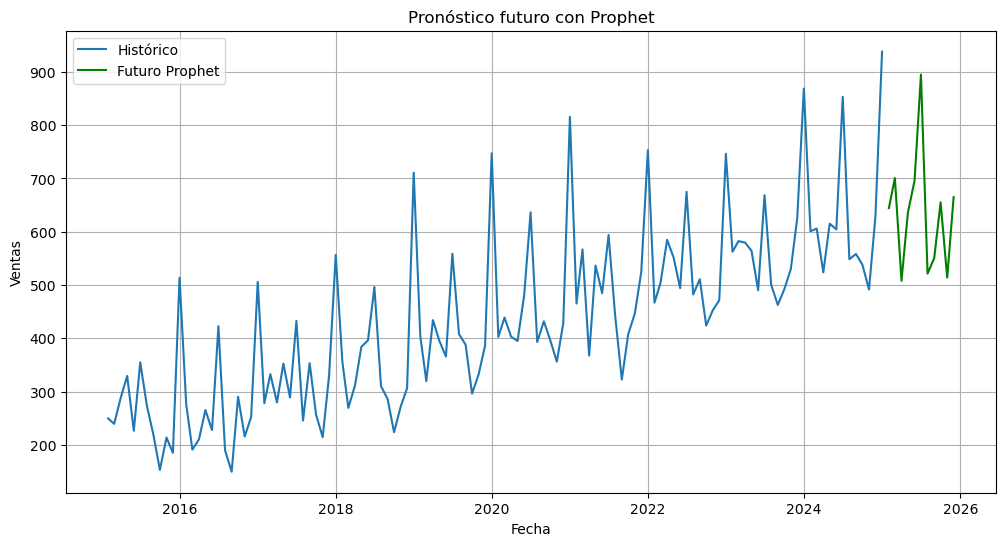

In [51]:
df_prophet = df.rename({'Fecha':'ds', 'Ventas':'y'}, axis=1)

modelo_prophet = Prophet()
modelo_prophet.fit(df_prophet)

future_prophet = modelo_prophet.make_future_dataframe(periods=n_months, freq='MS')
forecast_future = modelo_prophet.predict(future_prophet)
forecast_12meses = forecast_future.tail(n_months-1)

plt.figure(figsize=(12,6))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Histórico')
plt.plot(forecast_12meses['ds'], forecast_12meses['yhat'], label='Futuro Prophet', color='green')
plt.title('Pronóstico futuro con Prophet')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

## Conclusión y Recomendaciones Estratégicas
Una vez obtenidas las predicciones:

- Inventario: Aumentar producción en los meses con mayor demanda proyectada.

- Marketing: Realizar campañas específicas en los meses con ventas más bajas para compensar la caída.

- Finanzas: Ajustar flujo de efectivo y recursos de personal para meses clave.

